In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Load test set and its reconstruction from Telemanom-ESA
channel_names = [f"channel_{x}" for x in range(41,46 + 1)]
test_set = pd.read_parquet("/kaggle/input/esa-adb-challenge/test.parquet", columns=["id"] + channel_names)
reconstruction = pd.read_csv("/kaggle/input/telemanom-esa-baseline-channels41-46/tensorflow2/default/1/Telemanom-ESA-baseline-channels41-46/Telemanom-ESA/1b686e08c798457aa30dcfb02bd86868/ESA-Mission1/kaggle_test/1/model.h5.reconstruction.csv")

<Axes: >

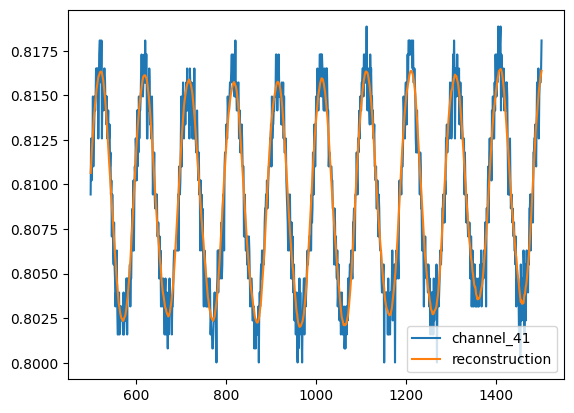

In [3]:
# Compare test set and reconstruction for channel 41
channel_name = "channel_41"
start_idx, end_idx = 500, 1500
pd.DataFrame({channel_name: test_set.loc[start_idx:end_idx, channel_name], 
              "reconstruction": reconstruction.loc[start_idx:end_idx, channel_name]}).plot()

In [4]:
# Load raw anomaly scores from Telemanom-ESA-channels41-46 (absolute differences between channel reconstructions and test data)
raw_scores = pd.read_csv("/kaggle/input/telemanom-esa-baseline-channels41-46/tensorflow2/default/1/Telemanom-ESA-baseline-channels41-46/Telemanom-ESA/1b686e08c798457aa30dcfb02bd86868/ESA-Mission1/kaggle_test/1/docker-algorithm-scores.csv", header=None)
raw_scores

,0,1,2,3,4,5
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
521275,0.001079,0.002180,0.000858,0.001838,0.001113,0.001915
521276,0.001082,0.002214,0.000859,0.001815,0.001100,0.001967
521277,0.001063,0.002281,0.000850,0.001808,0.001119,0.002039
521278,0.001062,0.002261,0.000847,0.001782,0.001119,0.002004


<Axes: >

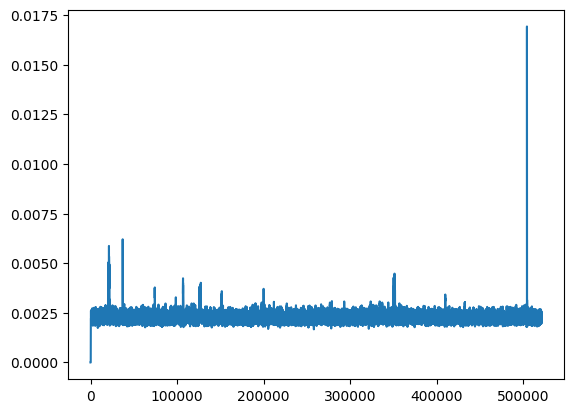

In [5]:
# Plot max-aggregated anomaly scores across channels
aggregated_raw_scores = raw_scores.max(axis=1)
aggregated_raw_scores.plot()

In [6]:
# Load binary anomaly scores after Telemanom thresholding without pruning
binary_scores = pd.read_csv("/kaggle/input/telemanom-esa-baseline-channels41-46/tensorflow2/default/1/Telemanom-ESA-baseline-channels41-46/Telemanom-ESA/1b686e08c798457aa30dcfb02bd86868/ESA-Mission1/kaggle_test/1/anomaly_scores_nonPruned.ts", header=None)
binary_scores

,0,1,2,3,4,5
0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
521275,0.0,0.0,0.0,0.0,0.0,0.0
521276,0.0,0.0,0.0,0.0,0.0,0.0
521277,0.0,0.0,0.0,0.0,0.0,0.0
521278,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: >

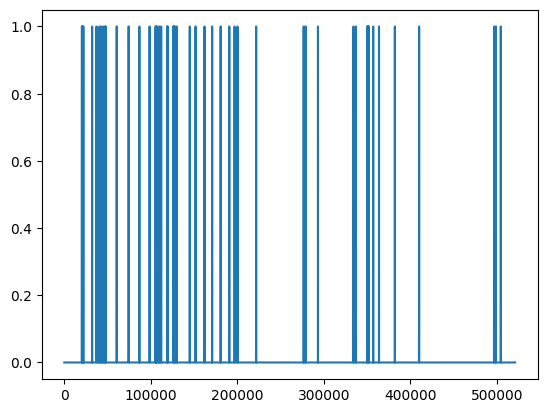

In [7]:
# Plot max-aggregated anomaly scores across channels
aggregated_binary_scores = binary_scores.max(axis=1)
aggregated_binary_scores.plot()

In [8]:
# Save to submission file
submission_df = pd.DataFrame()
submission_df["id"] = test_set["id"]
submission_df["is_anomaly"] = aggregated_binary_scores
submission_df.to_parquet(f"/kaggle/working/Telemanom-ESA-nonPruned-channels41-46.parquet")
# Generate a file supported by the Kaggle "Submit to competition" option
submission_df.to_csv(f"/kaggle/working/submission.csv", index=False)

<Axes: xlabel='id'>

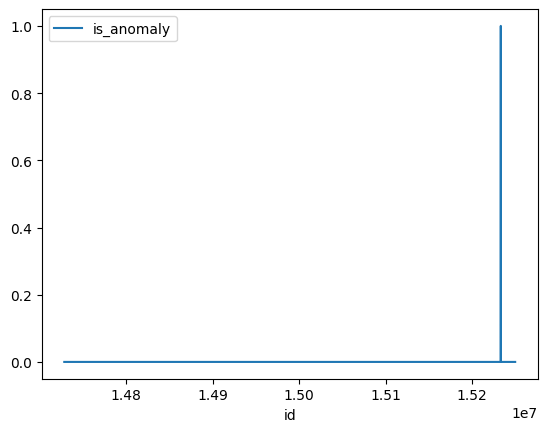

In [9]:
# Load and plot binary anomaly scores after Telemanom thresholding with pruning
pruned_binary_scores = pd.read_csv("/kaggle/input/telemanom-esa-baseline-channels41-46/tensorflow2/default/1/Telemanom-ESA-baseline-channels41-46/Telemanom-ESA/1b686e08c798457aa30dcfb02bd86868/ESA-Mission1/kaggle_test/1/anomaly_scores_Pruned.ts", header=None)
aggregated_pruned_binary_scores = pruned_binary_scores.max(axis=1)
submission_df["is_anomaly"] = aggregated_pruned_binary_scores
submission_df.to_parquet(f"/kaggle/working/Telemanom-ESA-Pruned-channels41-46.parquet")
submission_df.plot("id", "is_anomaly")